# Banco de prueba — MotorController + GRBL

Notebook para probar las funcionalidades básicas del controlador de motores usando **GRBL 1.1** sobre Arduino UNO + CNC Shield.

La idea es validar, en forma incremental:

- conexión serie
- estado de GRBL
- inicialización
- `Set Home` / `To Home`
- movimientos relativos y absolutos
- `jog` manual estilo `$J=`
- límites lógicos
- barridos de grilla

**Precaución:** comenzar con pasos chicos y velocidades bajas. Verificar que los motores no estén mecánicamente forzados antes de ejecutar movimientos.


## 1. Instalación de dependencias

Ejecutar una sola vez si falta `pyserial`.

In [ ]:
# !pip install pyserial

## 2. Importaciones y configuración inicial

Cambiar `PORT` según el sistema:

- Linux / Raspberry Pi: `/dev/ttyUSB0` o `/dev/ttyACM0`
- Windows: `COM3`, `COM4`, `COM5`, etc.

La velocidad típica de GRBL es `115200` baudios.

In [2]:
from pathlib import Path
import json
import time
import serial
from datetime import datetime
from typing import Callable, Optional, Union

# Cambiar según corresponda
PORT = "/dev/ttyUSB0"   # Linux / Raspberry Pi
# PORT = "COM5"         # Windows

BAUDRATE = 115200
TIMEOUT = 2


## 3. Clase `MotorController`

Pegar o mantener aquí la implementación actual de la clase. Esta versión incluye:

- movimientos relativos (`move_relative`)
- movimientos absolutos (`move_absolute`)
- jog manual (`jog` / `jog_cancel`)
- home lógico (`set_home` / `go_home`)
- límites lógicos
- barrido de grilla (`scan_grid`)

Si ya tenés la clase en un archivo `.py`, podés reemplazar esta celda por un import.

In [3]:
class MotorController:
    """
    Controlador de motores basado en GRBL por puerto serie.

    Modos principales:
    - move_relative / move_absolute: movimientos determinísticos con G1.
    - jog / jog_cancel: movimiento manual tipo joystick usando $J=.

    Incluye home lógico, persistencia de posición, historial de eventos,
    límites lógicos y barridos en grilla.
    """

    STATE_FILE = Path("motor_state.json")
    HISTORY_FILE = Path("motor_history.jsonl")

    def __init__(self, ser):
        self.ser = ser

        self.position = {"x": 0.0, "y": 0.0, "z": 0.0}
        self.home = {"x": 0.0, "y": 0.0, "z": 0.0}

        self.limits = {
            "x_min": -0.5,
            "x_max":  0.5,
            "y_min": -0.5,
            "y_max":  0.5,
            "z_min": -0.2,
            "z_max":  0.2,
        }
        self.limits_enabled = True

        self.load_state()

    def _now(self):
        return datetime.utcnow().isoformat(timespec="seconds") + "Z"

    def _readline(self):
        return self.ser.readline().decode(errors="ignore").strip()

    def _log_event(self, event: str, **data):
        row = {"ts": self._now(), "event": event, **data}
        with self.HISTORY_FILE.open("a", encoding="utf-8") as f:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    def save_state(self):
        data = {
            "home": self.home,
            "position": self.position,
            "limits": self.limits,
            "limits_enabled": self.limits_enabled,
            "updated_at": self._now(),
        }
        self.STATE_FILE.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")

    def load_state(self):
        if not self.STATE_FILE.exists():
            return
        try:
            data = json.loads(self.STATE_FILE.read_text(encoding="utf-8"))
            self.home = data.get("home", self.home)
            self.position = data.get("position", self.position)
            self.limits = data.get("limits", self.limits)
            self.limits_enabled = data.get("limits_enabled", self.limits_enabled)
        except Exception:
            pass

    def send(self, cmd: str):
        """Envía un comando estándar y espera ok/error."""
        self.ser.write((cmd.strip() + "\n").encode())
        self.ser.flush()
        while True:
            r = self._readline()
            if not r:
                continue
            rl = r.lower()
            if rl.startswith("ok") or rl.startswith("error"):
                return r

    def status(self):
        """Consulta estado en tiempo real con '?'."""
        self.ser.write(b"?")
        self.ser.flush()
        return self._readline()

    def initialize(self, feed: float = 80.0):
        self.send("$X")
        self.send("G21")
        self.send(f"F{feed:.2f}")
        self._log_event("initialize", feed=feed)

    def set_limits(self, x_min=None, x_max=None, y_min=None, y_max=None, z_min=None, z_max=None):
        updates = {
            "x_min": x_min, "x_max": x_max,
            "y_min": y_min, "y_max": y_max,
            "z_min": z_min, "z_max": z_max,
        }
        for key, value in updates.items():
            if value is not None:
                self.limits[key] = float(value)
        self._validate_limits_definition()
        self.save_state()
        self._log_event("set_limits", **self.limits)

    def enable_limits(self):
        self.limits_enabled = True
        self.save_state()
        self._log_event("enable_limits")

    def disable_limits(self):
        self.limits_enabled = False
        self.save_state()
        self._log_event("disable_limits")

    def _validate_limits_definition(self):
        if self.limits["x_min"] >= self.limits["x_max"]:
            raise ValueError("Límites inválidos: x_min debe ser menor que x_max")
        if self.limits["y_min"] >= self.limits["y_max"]:
            raise ValueError("Límites inválidos: y_min debe ser menor que y_max")
        if self.limits["z_min"] >= self.limits["z_max"]:
            raise ValueError("Límites inválidos: z_min debe ser menor que z_max")

    def _check_limits(self, x: float, y: float, z: float):
        if not self.limits_enabled:
            return
        errors = []
        if not (self.limits["x_min"] <= x <= self.limits["x_max"]):
            errors.append(f"X={x:.4f} mm fuera de rango [{self.limits['x_min']:.4f}, {self.limits['x_max']:.4f}]")
        if not (self.limits["y_min"] <= y <= self.limits["y_max"]):
            errors.append(f"Y={y:.4f} mm fuera de rango [{self.limits['y_min']:.4f}, {self.limits['y_max']:.4f}]")
        if not (self.limits["z_min"] <= z <= self.limits["z_max"]):
            errors.append(f"Z={z:.4f} mm fuera de rango [{self.limits['z_min']:.4f}, {self.limits['z_max']:.4f}]")
        if errors:
            message = "ALERTA: movimiento fuera de límites operativos. " + " | ".join(errors)
            self._log_event("limit_exceeded", requested_x=x, requested_y=y, requested_z=z, message=message, **self.limits)
            raise ValueError(message)

    def set_home(self):
        response = self.send("G92 X0 Y0 Z0")
        self.position = {"x": 0.0, "y": 0.0, "z": 0.0}
        self.home = {"x": 0.0, "y": 0.0, "z": 0.0}
        self.save_state()
        self._log_event("set_home", x=0.0, y=0.0, z=0.0)
        return response

    def go_home(self, feed: float = 80.0):
        return self.move_absolute(x=self.home["x"], y=self.home["y"], z=self.home["z"], feed=feed)

    def move_relative(self, dx: float = 0.0, dy: float = 0.0, dz: float = 0.0, feed: float = 80.0):
        target_x = self.position["x"] + dx
        target_y = self.position["y"] + dy
        target_z = self.position["z"] + dz
        self._check_limits(target_x, target_y, target_z)

        self.send("G91")
        self.send(f"F{feed:.2f}")
        cmd = "G1"
        if dx != 0.0:
            cmd += f" X{dx:.4f}"
        if dy != 0.0:
            cmd += f" Y{dy:.4f}"
        if dz != 0.0:
            cmd += f" Z{dz:.4f}"
        response = self.send(cmd)

        self.position["x"] = target_x
        self.position["y"] = target_y
        self.position["z"] = target_z
        self.save_state()
        self._log_event("move_relative", dx=dx, dy=dy, dz=dz, feed=feed, **self.position)
        return response

    def move_absolute(self, x=None, y=None, z=None, feed: float = 80.0):
        self.send("G90")
        self.send(f"F{feed:.2f}")

        tx = self.position["x"] if x is None else x
        ty = self.position["y"] if y is None else y
        tz = self.position["z"] if z is None else z
        self._check_limits(tx, ty, tz)

        response = self.send(f"G1 X{tx:.4f} Y{ty:.4f} Z{tz:.4f}")
        self.position["x"] = tx
        self.position["y"] = ty
        self.position["z"] = tz
        self.save_state()
        self._log_event("move_absolute", x=tx, y=ty, z=tz, feed=feed)
        return response

    def jog(self, dx: float = 0.0, dy: float = 0.0, dz: float = 0.0, feed: float = 80.0):
        target_x = self.position["x"] + dx
        target_y = self.position["y"] + dy
        target_z = self.position["z"] + dz
        self._check_limits(target_x, target_y, target_z)

        cmd = "$J=G91"
        if dx != 0.0:
            cmd += f" X{dx:.4f}"
        if dy != 0.0:
            cmd += f" Y{dy:.4f}"
        if dz != 0.0:
            cmd += f" Z{dz:.4f}"
        cmd += f" F{feed:.2f}"

        self.ser.write((cmd + "\n").encode())
        self.ser.flush()

        self.position["x"] = target_x
        self.position["y"] = target_y
        self.position["z"] = target_z
        self.save_state()
        self._log_event("jog", dx=dx, dy=dy, dz=dz, feed=feed, **self.position)

    def jog_cancel(self):
        self.ser.write(b"\x85")
        self.ser.flush()
        self._log_event("jog_cancel")

    def _generate_grid_points(self, rows: int, cols: int, step: float, pattern: str = "zigzag", centered: bool = False):
        if rows < 1 or cols < 1:
            raise ValueError("rows y cols deben ser >= 1")
        if step <= 0:
            raise ValueError("step debe ser > 0")

        x0 = -((cols - 1) * step) / 2.0 if centered else 0.0
        y0 = -((rows - 1) * step) / 2.0 if centered else 0.0

        if pattern == "raster":
            return [(x0 + c * step, y0 + r * step) for r in range(rows) for c in range(cols)]

        if pattern == "zigzag":
            pts = []
            for r in range(rows):
                cols_iter = range(cols) if r % 2 == 0 else range(cols - 1, -1, -1)
                for c in cols_iter:
                    pts.append((x0 + c * step, y0 + r * step))
            return pts

        if pattern == "spiral":
            # Recorre primero los puntos más cercanos al centro.
            grid = [(r, c) for r in range(rows) for c in range(cols)]
            center_r = (rows - 1) / 2.0
            center_c = (cols - 1) / 2.0
            grid.sort(key=lambda rc: (rc[0] - center_r) ** 2 + (rc[1] - center_c) ** 2)
            return [(x0 + c * step, y0 + r * step) for r, c in grid]

        raise ValueError(f"Patrón no soportado: {pattern}")

    def scan_grid(self, rows: int, cols: int, step: float, feed: float, pattern: str = "zigzag", centered: bool = False,
                  reverse: bool = False, wait_mode: str = "none", delay_s: float = 0.0,
                  on_point: Optional[Callable[[int, float, float], Union[bool, dict]]] = None,
                  on_fail: str = "retry", return_home: bool = False):
        points = self._generate_grid_points(rows=rows, cols=cols, step=step, pattern=pattern, centered=centered)

        if reverse:
            points = list(reversed(points))

        # Validación preventiva: evita iniciar una grilla que excede límites.
        for x, y in points:
            self._check_limits(x, y, self.position["z"])

        self._log_event("scan_grid_start", rows=rows, cols=cols, step=step, feed=feed,
                        pattern=pattern, centered=centered, reverse=reverse,
                        wait_mode=wait_mode, delay_s=delay_s, on_fail=on_fail)

        i = 0
        try:
            while i < len(points):
                x, y = points[i]
                self.move_absolute(x=x, y=self.position["y"], z=y, feed=feed)
                self._log_event("scan_grid_point", index=i, x=x, y=self.position["y"], z=y)

                point_ok = True
                result = None

                if on_point is not None:
                    result = on_point(i, x, y)
                    if isinstance(result, bool):
                        point_ok = result
                    elif isinstance(result, dict):
                        point_ok = bool(result.get("ok", True))

                if point_ok:
                    if wait_mode == "delay" and delay_s > 0:
                        time.sleep(delay_s)
                    elif wait_mode == "user":
                        input(f"Punto {i} listo en ({x:.4f}, {y:.4f}). Enter para continuar...")
                    i += 1
                    continue

                self._log_event("scan_grid_point_failed", index=i, x=x, y=self.position["y"], z=y, result=result)
                action = on_fail
                if isinstance(result, dict) and "action" in result:
                    action = result["action"]

                if action == "retry":
                    continue
                if action == "skip":
                    i += 1
                    continue
                if action == "abort":
                    self._log_event("scan_grid_abort", index=i, x=x, y=y, z=self.position["z"], result=result)
                    break
                if action == "wait_user":
                    user = input(f"Fallo en punto {i} ({x:.4f}, {y:.4f}). [c] continuar, [r] reintentar, [s] saltear, [a] abortar: ").strip().lower()
                    if user == "r":
                        continue
                    if user == "s":
                        i += 1
                        continue
                    if user == "a":
                        self._log_event("scan_grid_abort_user", index=i, x=x, y=y, z=self.position["z"])
                        break
                    i += 1
                    continue

                raise ValueError(f"Acción on_fail no soportada: {action}")

        finally:
            if return_home:
                self.go_home(feed=feed)
            self._log_event("scan_grid_end")


## 4. Abrir conexión serie

Esta celda abre el puerto serie y crea el controlador. Si el puerto no existe o está ocupado, revisar que UGS u otro programa no lo tenga abierto.

In [4]:
ser = serial.Serial(PORT, BAUDRATE, timeout=TIMEOUT)
time.sleep(2.0)  # GRBL suele resetear al abrir puerto

controller = MotorController(ser)
print("Conectado a", PORT)

Conectado a /dev/ttyUSB0


## 5. Test de estado GRBL

Consulta el estado con `?`. Debería devolver algo tipo `Idle`, `Run`, `Alarm`, etc.

In [8]:
controller.status()

'<Idle|MPos:2.000,0.000,0.000|FS:0,0>'

## 6. Inicialización básica

Ejecuta `$X`, `G21` y define una velocidad inicial. `$X` desbloquea GRBL si está en estado `Alarm`.

In [9]:
controller.initialize(feed=50.0)
print(controller.status())

<Idle|MPos:2.000,0.000,0.000|FS:0,0>


## 7. Configurar límites lógicos

Los límites evitan movimientos fuera de la región segura. Están activos por defecto.

Ajustar estos valores al rango seguro real del conjunto motor–acople antibacklash–tornillo.

In [10]:
controller.set_limits(
    x_min=-5.0, x_max=5.0,
    y_min=-5.0, y_max=5.0,
    z_min=-5.0, z_max=5.0,
)
controller.enable_limits()
print(controller.limits)
print("Límites activos:", controller.limits_enabled)

{'x_min': -5.0, 'x_max': 5.0, 'y_min': -5.0, 'y_max': 5.0, 'z_min': -5.0, 'z_max': 5.0}
Límites activos: True


## 8. Set Home

`set_home()` define la posición actual como `(0,0,0)` usando `G92 X0 Y0 Z0`.

Usarlo cuando el sistema esté en la posición que se quiere tomar como referencia inicial.

In [11]:
controller.set_home()
print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 9. Test de movimiento relativo

Movimiento determinístico con `G1` en modo incremental. Es el modo recomendado para automatización y barridos.

Este ejemplo mueve X un paso y vuelve.

In [13]:
STEP = 1.0
FEED = 30.0

controller.move_relative(dx=STEP, feed=FEED)
time.sleep(0.5)
controller.move_relative(dx=-STEP, feed=FEED)

print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 10. Test de ejes X, Y y Z

Prueba un pequeño movimiento positivo y negativo en cada eje. Usar valores chicos.

In [16]:
STEP = 1.0
FEED = 50.0

for axis in ["x", "y", "z"]:
    kwargs = {f"d{axis}": STEP, "feed": FEED}
    controller.move_relative(**kwargs)
    time.sleep(0.3)
    kwargs = {f"d{axis}": -STEP, "feed": FEED}
    controller.move_relative(**kwargs)
    time.sleep(0.3)

print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 11. Test de movimiento absoluto y To Home

`move_absolute()` usa `G90`. `go_home()` vuelve al home lógico definido.

In [ ]:
controller.move_absolute(x=3.0, y=0.5, z=3.0, feed=200.0)
print("Posición:", controller.position)

time.sleep(1.0)
print("Moving to home...")
for n in range(10):
    print(f"{10-n}..." , end=" ")
    time.sleep(0.5)
print("")
controller.go_home(feed=30.0)
print("Posición luego de go_home:", controller.position)

Posición: {'x': 5.0, 'y': 0.5, 'z': 3.0}
Moving to home...
10... 9... 8... 7... 6... 5... 4... 3... 2... 1... 
Posición luego de go_home: {'x': 0.0, 'y': 0.0, 'z': 0.0}


## 12. Test de `jog` manual tipo UGS

Usa `$J=G91...`. Es útil para control manual tipo joystick.

Para rutinas automáticas, conviene usar `move_relative()`.

In [40]:
controller.jog(dx=0.1, feed=20.0)
time.sleep(0.5)
controller.jog(dx=-0.1, feed=20.0)

print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 13. Test de cancelación de jog

`jog_cancel()` envía el comando realtime `0x85`. Es útil si después se implementa un joystick continuo.

In [60]:
# Ejemplo conservador: se lanza un jog pequeño y luego se cancela.
controller.jog(dx=2.0, feed=100.0)
time.sleep(5)
print("Jog canelling")
controller.jog_cancel()
print(controller.status())

Jog canelling
ok


## 14. Test de límites lógicos

Este test intenta mover fuera del rango permitido. Debería generar una excepción `ValueError` y no mover el motor.

In [43]:
try:
    controller.move_absolute(x=999.0, y=0.0, z=0.0, feed=30.0)
except ValueError as exc:
    print("Límite detectado correctamente:")
    print(exc)

Límite detectado correctamente:
ALERTA: movimiento fuera de límites operativos. X=999.0000 mm fuera de rango [-5.0000, 5.0000]


## 15. Visualizar puntos de una grilla sin mover

Esto permite verificar el patrón antes de ejecutarlo físicamente.

In [38]:
points = controller._generate_grid_points(rows=8, cols=8, step=0.5, pattern="zigzag", centered=True)
for i, p in enumerate(points):
    print(i, p)

0 (-1.75, -1.75)
1 (-1.25, -1.75)
2 (-0.75, -1.75)
3 (-0.25, -1.75)
4 (0.25, -1.75)
5 (0.75, -1.75)
6 (1.25, -1.75)
7 (1.75, -1.75)
8 (1.75, -1.25)
9 (1.25, -1.25)
10 (0.75, -1.25)
11 (0.25, -1.25)
12 (-0.25, -1.25)
13 (-0.75, -1.25)
14 (-1.25, -1.25)
15 (-1.75, -1.25)
16 (-1.75, -0.75)
17 (-1.25, -0.75)
18 (-0.75, -0.75)
19 (-0.25, -0.75)
20 (0.25, -0.75)
21 (0.75, -0.75)
22 (1.25, -0.75)
23 (1.75, -0.75)
24 (1.75, -0.25)
25 (1.25, -0.25)
26 (0.75, -0.25)
27 (0.25, -0.25)
28 (-0.25, -0.25)
29 (-0.75, -0.25)
30 (-1.25, -0.25)
31 (-1.75, -0.25)
32 (-1.75, 0.25)
33 (-1.25, 0.25)
34 (-0.75, 0.25)
35 (-0.25, 0.25)
36 (0.25, 0.25)
37 (0.75, 0.25)
38 (1.25, 0.25)
39 (1.75, 0.25)
40 (1.75, 0.75)
41 (1.25, 0.75)
42 (0.75, 0.75)
43 (0.25, 0.75)
44 (-0.25, 0.75)
45 (-0.75, 0.75)
46 (-1.25, 0.75)
47 (-1.75, 0.75)
48 (-1.75, 1.25)
49 (-1.25, 1.25)
50 (-0.75, 1.25)
51 (-0.25, 1.25)
52 (0.25, 1.25)
53 (0.75, 1.25)
54 (1.25, 1.25)
55 (1.75, 1.25)
56 (1.75, 1.75)
57 (1.25, 1.75)
58 (0.75, 1.75)
59 (0.

## 16. Barrido de grilla con delay

Recorre una grilla chica centrada alrededor del home. Usar `return_home=True` para volver al origen al finalizar.

In [39]:
controller.set_home()

controller.scan_grid(
    rows=3,
    cols=3,
    step=0.5,
    feed=100.0,
    pattern="spiral",
    centered=True,
    wait_mode="delay",
    delay_s=0.5,
    return_home=True,
)

print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 17. Barrido con callback de medición simulada

El callback se ejecuta en cada punto. Acá se simula una medición; luego se puede reemplazar por adquisición real del LIDAR.

In [48]:
measurements = []

def fake_measurement(i, x, y):
    print(f"Midiendo en punto {i}...")
    time.sleep(3.0)  # Simula tiempo de medición
    value = 1.0  # reemplazar por medición real
    measurements.append({"index": i, "x": x, "y": y, "value": value})
    print(f"Medición {i}: X={x:.4f}, Y={y:.4f}, value={value}")
    return {"ok": True}

controller.set_home()
controller.scan_grid(
    rows=3,
    cols=3,
    step=0.5,
    feed=50.0,
    pattern="raster",
    centered=True,
    wait_mode="callback",
    on_point=fake_measurement,
    return_home=True,
)

measurements

Midiendo en punto 0...
Medición 0: X=-0.5000, Y=-0.5000, value=1.0
Midiendo en punto 1...
Medición 1: X=0.0000, Y=-0.5000, value=1.0
Midiendo en punto 2...
Medición 2: X=0.5000, Y=-0.5000, value=1.0
Midiendo en punto 3...
Medición 3: X=-0.5000, Y=0.0000, value=1.0
Midiendo en punto 4...
Medición 4: X=0.0000, Y=0.0000, value=1.0
Midiendo en punto 5...
Medición 5: X=0.5000, Y=0.0000, value=1.0
Midiendo en punto 6...
Medición 6: X=-0.5000, Y=0.5000, value=1.0
Midiendo en punto 7...
Medición 7: X=0.0000, Y=0.5000, value=1.0
Midiendo en punto 8...
Medición 8: X=0.5000, Y=0.5000, value=1.0


[{'index': 0, 'x': -0.5, 'y': -0.5, 'value': 1.0},
 {'index': 1, 'x': 0.0, 'y': -0.5, 'value': 1.0},
 {'index': 2, 'x': 0.5, 'y': -0.5, 'value': 1.0},
 {'index': 3, 'x': -0.5, 'y': 0.0, 'value': 1.0},
 {'index': 4, 'x': 0.0, 'y': 0.0, 'value': 1.0},
 {'index': 5, 'x': 0.5, 'y': 0.0, 'value': 1.0},
 {'index': 6, 'x': -0.5, 'y': 0.5, 'value': 1.0},
 {'index': 7, 'x': 0.0, 'y': 0.5, 'value': 1.0},
 {'index': 8, 'x': 0.5, 'y': 0.5, 'value': 1.0}]

## 18. Barrido con fallo simulado

Este test simula que un punto falla y pide acción manual. Para pruebas automáticas puede usarse `on_fail='skip'` o `on_fail='abort'`.

In [58]:
def fake_measurement_with_failure(i, x, y):
    if i == 1:
        return {"ok": False, "action": "skip", "reason": "fallo simulado"}
    return {"ok": True}

#controller.set_home()
controller.scan_grid(
    rows=3,
    cols=3,
    step=0.5,
    feed=20.0,
    pattern="zigzag",
    centered=True,
    wait_mode="callback",
    on_point=fake_measurement_with_failure,
    on_fail="skip",
    return_home=True,
)

print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 19. Barrido con callback real conectado a osciloscopio

Hacemos un barrido llamado a una captura de señales del osciloscopio ejecutando clase oscrigol

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt
from oscrigol import oscrigol



In [ ]:
scope = oscrigol("192.168.2.2")

scope.config(
    channels=(1,),
    chanBand=("OFF",),
    chanCoup=("AC",),
    chanInv=("OFF",),
    chanImp=("OMEG",),
    trigSource="CHAN1",
    trigCoup="DC",
    trigLevel=0.0,
    trigSlope="POS",
    acquisition=1,
    mdepth=14000
)

scope.initComm()
scope.setEdgeTrigger("CHAN1", "POS", "DC", 20e-3)
scope.setChannel(1, "OFF", "AC", "OFF", "FIFTy")

print(scope.getID())
scope.closeComm()

RIGOL TECHNOLOGIES,MSO2102A,DS2F214100395,00.03.06



In [27]:
tmeas = []
vmeas = []

def oscrigol_measurement(i, x, y):
    
    print(f"Medición en punto {i} con osciloscopio...")
    print(f"Medición {i}: X={x:.4f}, Y={y:.4f}")
    scope.initComm()

    scope.autoAdjustVertScale(
        channels=(1,),
        mode="PEAK",
        n_iter=2,
        target_divisions=8.0,
        min_divisions=6.0,
        max_divisions=7.5,
        use_scope_steps=False,
        acq_wait=0.5,
        settle_wait=0.2,
        verbose=True
    )
    
    # Detener adquisición y leer datos de canal 1
    scope.stop()
    t = scope.getHorValues(mdepth=140000)  # Leer valores horizontales (tiempo)
    v = scope.getVertValues(channel=1, mem_depth=140000,delay_time=3.0)  # Leer valores verticales (voltaje)
    scope.run()

    scope.closeComm()

    tmeas.append(t)
    vmeas.append(v)

    return {"ok": True, "tmeas": tmeas, "vmeas": vmeas}

controller.scan_grid(
    rows=3,
    cols=3,
    step=0.5,
    feed=100.0,
    pattern="raster",
    centered=True,
    wait_mode="callback",
    on_point=oscrigol_measurement,
    on_fail="skip",
    return_home=True,
)

print(controller.position)

Medición en punto 0 con osciloscopio...
Medición 0: X=-0.5000, Y=-0.5000

AutoAdjust vertical - iteración 1/2
CH1: medición fuera de rango (Vmin=9.9e+37, Vmax=9.9e+37)
CH1: recuperación -> scale=0.02019 → 0.04038 V/div, offset=-0.00943 → 0 V

AutoAdjust vertical - iteración 2/2
CH1: medición fuera de rango (Vmin=9.9e+37, Vmax=9.9e+37)
CH1: recuperación -> scale=0.04038 → 0.08077 V/div, offset=0 → 0 V
Medición en punto 1 con osciloscopio...
Medición 1: X=0.0000, Y=-0.5000

AutoAdjust vertical - iteración 1/2
CH1: Vmin=-0.1066 V, Vmax=0.1486 V, Vpp=0.2552 V, usado=3.16 div
CH1: ajuste -> scale=0.08077 → 0.0319 V/div, offset=0 → -0.021 V

AutoAdjust vertical - iteración 2/2
CH1: Vmin=-0.1066 V, Vmax=0.1486 V, Vpp=0.2552 V, usado=8.00 div
CH1: ajuste -> scale=0.0319 → 0.0319 V/div, offset=-0.021 → -0.021 V
Medición en punto 2 con osciloscopio...
Medición 2: X=0.5000, Y=-0.5000

AutoAdjust vertical - iteración 1/2
CH1: Vmin=-0.1008 V, Vmax=0.1378 V, Vpp=0.2386 V, usado=7.48 div
CH1: no requ

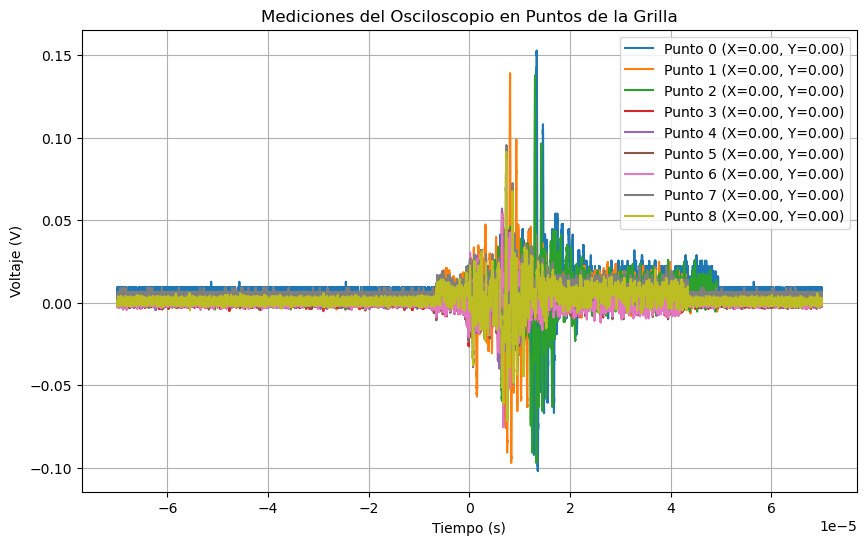

In [28]:
# Graficar mediciones del osciloscopio superpuestas en un mismo gráfico
# leyenda con índice de punto y coordenadas
plt.figure(figsize=(10, 6))
for i, (t, v) in enumerate(zip(tmeas, vmeas)):
    plt.plot(t, v, label=f"Punto {i} (X={controller.position['x']:.2f}, Y={controller.position['y']:.2f})")
plt.title("Mediciones del Osciloscopio en Puntos de la Grilla")
plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (V)")
plt.legend()
plt.grid()


## 20. Revisar archivos de estado e historial

Permite verificar qué quedó guardado en `motor_state.json` y las últimas líneas del historial.

In [61]:
print("Estado actual:")
print(Path("motor_state.json").read_text(encoding="utf-8"))

print("\nÚltimos eventos:")
history = Path("motor_history.jsonl")
if history.exists():
    lines = history.read_text(encoding="utf-8").splitlines()
    for line in lines[-10:]:
        print(line)

Estado actual:
{
  "home": {
    "x": 0.0,
    "y": 0.0,
    "z": 0.0
  },
  "position": {
    "x": 2.0,
    "y": 0.0,
    "z": 0.0
  },
  "limits": {
    "x_min": -5.0,
    "x_max": 5.0,
    "y_min": -5.0,
    "y_max": 5.0,
    "z_min": -5.0,
    "z_max": 5.0
  },
  "limits_enabled": true,
  "updated_at": "2026-05-12T17:06:08Z"
}

Últimos eventos:
{"ts": "2026-05-12T16:57:48Z", "event": "move_absolute", "x": -0.5, "y": 0.0, "z": 0.5, "feed": 20.0}
{"ts": "2026-05-12T16:57:48Z", "event": "scan_grid_point", "index": 6, "x": -0.5, "y": 0.0, "z": 0.5}
{"ts": "2026-05-12T16:57:48Z", "event": "move_absolute", "x": 0.0, "y": 0.0, "z": 0.5, "feed": 20.0}
{"ts": "2026-05-12T16:57:48Z", "event": "scan_grid_point", "index": 7, "x": 0.0, "y": 0.0, "z": 0.5}
{"ts": "2026-05-12T16:57:48Z", "event": "move_absolute", "x": 0.5, "y": 0.0, "z": 0.5, "feed": 20.0}
{"ts": "2026-05-12T16:57:48Z", "event": "scan_grid_point", "index": 8, "x": 0.5, "y": 0.0, "z": 0.5}
{"ts": "2026-05-12T16:57:48Z", "event": "

## 22. Cerrar puerto serie

Cerrar el puerto al finalizar para que pueda usarlo UGS u otra aplicación.

In [22]:
ser.close()
print("Puerto cerrado")

Puerto cerrado
